# Intuition of Eigenvalues & Eigenvectors

## 1. The Fundamental Problem
When a matrix transformation acts on a vector space, it typically rotates, twists, and stretches vectors in complex ways. This makes tracking multi-dimensional data transformations mathematically heavy.

## 2. The Solution
**Eigenvectors** are special, non-zero vectors whose direction remains completely unchanged during a matrix transformation. Instead of rotating, they are simply scaled (stretched or compressed).

The factor by which an eigenvector stretches is its corresponding **eigenvalue**.

## 3. The Fundamental Equation
The relationship between a square matrix $A$, an eigenvector $v$, and its eigenvalue $\lambda$ is defined by:

$$Av = \lambda v$$

Where:
* $A$ is an $n \times n$ square matrix.
* $v$ is a non-zero $n \times 1$ column vector (**eigenvector**).
* $\lambda$ is a scalar value (**eigenvalue**).


# Calculation

To calculate eigenvalues and eigenvectors manually, use the following algebraic sequence:

### Step 1: Form the Characteristic Equation
To find $\lambda$ without knowing $v$, we rearrange the fundamental equation into a homogeneous system:
$$(A - \lambda I)v = 0$$

For a non-zero vector $v$ to exist, the matrix $(A - \lambda I)$ must be non-invertible. Therefore, its determinant must equal zero:
$$\det(A - \lambda I) = 0$$
*(Note: $I$ is the identity matrix matching the dimensions of $A$.)*

### Step 2: Solve for Eigenvalues
Expanding the determinant yields a polynomial of degree $n$ (the characteristic polynomial). The roots of this polynomial are your eigenvalues ($\lambda_1, \lambda_2, \dots, \lambda_n$).

### Step 3: Solve for Eigenvectors
For each eigenvalue $\lambda$, substitute it back into the system matrix equation:
$$(A - \lambda I)v = 0$$

Solve the resulting system of linear equations using Gaussian elimination to find the basis for the null space. This basis forms your eigenvectors.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [6]:
    
def eigen(n):
    
    #Initializing the random number genrator(rng)
    rng=np.random.default_rng(seed=56)

    #Matric M containg randomply genrated entries
    M=rng.standard_normal(size=(n,n))

    #making it symetrical
    A=(M + M.T)/2


    print(f"Genrated {n}x{n} Matrix : \n",M)
    print("Symmetrical Matrix :\n",A)
    print("---"*20)

    #computing eigen values and eigenvectors
    eigenVal,eigenVec=np.linalg.eig(A)
    
    for i in range(n):
        print(f"Eigen Value{i+1}=",np.round(eigenVal[i],4))
        print(f"Eigen Vector :",eigenVec[:,i])
        print("---"*20)
        
    
    #verify orthogonality of eigen vectors
    all_orthogonal=True
    
    for i in range(n):
        for j in range(i+1,n):
            dot_product =np.dot(eigenVec[:,i],eigenVec[:,j])
            print(f"chcking vector {i} and vecctor {j} -- >dot product : {np.round(abs(dot_product),4)}")
            
            if not np.allclose(dot_product,0.0):
                all_orthogonal=False
        
    print("---"*20)        
                
            
    return all_orthogonal,A

status,A=eigen(3)
print("Is Eigen vectors Orthogonal ? :",status)    
        

Genrated 3x3 Matrix : 
 [[-0.84994072  0.32194085  1.78904286]
 [ 0.8793392   0.37159282  1.48769378]
 [ 0.72866553  2.08124873 -1.33726808]]
Symmetrical Matrix :
 [[-0.84994072  0.60064002  1.25885419]
 [ 0.60064002  0.37159282  1.78447126]
 [ 1.25885419  1.78447126 -1.33726808]]
------------------------------------------------------------
Eigen Value1= 2.0049
Eigen Vector : [-0.39559303 -0.73992474 -0.54407494]
------------------------------------------------------------
Eigen Value2= -1.0184
Eigen Vector : [-0.8201749   0.55119975 -0.15327089]
------------------------------------------------------------
Eigen Value3= -2.8021
Eigen Vector : [-0.4133029  -0.38560371  0.82491848]
------------------------------------------------------------
chcking vector 0 and vecctor 1 -- >dot product : 0.0
chcking vector 0 and vecctor 2 -- >dot product : 0.0
chcking vector 1 and vecctor 2 -- >dot product : 0.0
------------------------------------------------------------
Is Eigen vectors Orthogonal ? 

In [7]:
def verify_eigen(A):
    
    n=A.shape[0]
    verify_status=True
    eigenVal,eigenVec=np.linalg.eig(A)
    
    print("---"*20)
    #Characterstick equation A@V=lam*V
    for i in range(n):
        #L.H.S
        left=A@eigenVec[:,i]
        #R.H.S 
        right=eigenVal[i]*eigenVec[:,i]
        
        print(f"A@V{i+1} :",np.round(left,4))
        print(f"lam*V{i+1} :",np.round(right,4))
        print("---"*20)
        
        if not np.allclose(left,right):
            verify_status=False
    
    return verify_status        
            
        
print("All close ? :",verify_eigen(A))      
    
    
    
    

------------------------------------------------------------
A@V1 : [-0.7931 -1.4834 -1.0908]
lam*V1 : [-0.7931 -1.4834 -1.0908]
------------------------------------------------------------
A@V2 : [ 0.8352 -0.5613  0.1561]
lam*V2 : [ 0.8352 -0.5613  0.1561]
------------------------------------------------------------
A@V3 : [ 1.1581  1.0805 -2.3115]
lam*V3 : [ 1.1581  1.0805 -2.3115]
------------------------------------------------------------
All close ? : True


# The Concept of Diagonalization

## 1. What is Diagonalization?
Diagonalization is the process of breaking down a complex square matrix $A$ into a **diagonal matrix** $D$ (a matrix where numbers only exist on the main diagonal, and every other entry is zero).

A diagonal matrix is incredibly efficient. To compute $D^{100}$, you do not need matrix multiplication; you simply raise the individual diagonal elements to the power of 100:
$$D^{100} = \begin{bmatrix} \lambda_1^{100} & 0 \\ 0 & \lambda_2^{100} \end{bmatrix}$$

## 2. The Mathematical Formula
If an $n \times n$ matrix $A$ has $n$ linearly independent eigenvectors, it can be factored as:

$$A = PDP^{-1}$$

Where:
* **$P$ (The Eigenvector Matrix):** A matrix whose columns are the eigenvectors of $A$.
* **$D$ (The Eigenvalue Matrix):** A diagonal matrix whose entries are the eigenvalues of $A$.
* **$P^{-1}$:** The inverse of the eigenvector matrix.

## 3. Computational Superpower
When raising $A$ to a high power, the internal matrix inverses cancel out perfectly:
$$A^k = (PDP^{-1})(PDP^{-1})\dots(PDP^{-1}) = P D^k P^{-1}$$

This turns a massive supercomputer task involving billions of matrix calculations into a near-instantaneous scalar calculation.

## 4. When Diagonalization Fails (Deficient Matrices)
Not all matrices can be diagonalized. To build a full matrix $P$, you must have $n$ linearly independent eigenvectors. If a matrix skews or shears space (like $\begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}$), it lacks enough independent directions. These are called **deficient matrices** and cannot be diagonalized.


# Topic 6: The Spectral Theorem & Symmetric Matrices

## 1. The Superpowers of Symmetric Matrices
A matrix is symmetric if it mirrors itself across the main diagonal ($A = A^T$). For real symmetric matrices, the **Spectral Theorem** guarantees three remarkable geometric traits:
1. **All eigenvalues are pure real numbers** (there is no hidden complex-number rotation).
2. **The matrix is always fully diagonalizable** (it can never fall into the shear mapping trap).
3. **Eigenvectors from different eigenvalues are perfectly perpendicular (orthogonal)** ($v_1 \cdot v_2 = 0$).

## 2. Upgrading the Formula: $A = QDQ^T$
If we divide each perpendicular eigenvector by its length, they become unit vectors (**orthonormal**). 

When we bundle these orthonormal vectors into a coordinate matrix, we call it **$Q$** (an orthogonal matrix). Orthogonal matrices have an incredible computational property: **their inverse is simply their transpose**.

$$Q^{-1} = Q^T$$

This eliminates the need for complex matrix inversion algorithms. The diagonalization formula upgrades to:

$$A = QDQ^T$$

## 3. Strict Order Matching Requirement
When assembling $Q$ and $D$, the positioning must match perfectly. If the eigenvector $u_1$ sits in the first column of $Q$, its corresponding eigenvalue $\lambda_1$ **must** sit in the first diagonal position $(1,1)$ of $D$:

$$Q = \begin{bmatrix} | & | \\ u_1 & u_2 \\ | & | \end{bmatrix} \iff D = \begin{bmatrix} \lambda_1 & 0 \\ 0 & \lambda_2 \end{bmatrix}$$

Swapping the columns of $Q$ is completely valid, provided you swap the corresponding rows/columns of $D$ to preserve the eigenvalue-eigenvector pairings.


In [8]:
def diagonalisation(A):
    eigenVal,eigenVec=np.linalg.eig(A)
    #As Matrix A is symetric so By Spectral Theorem ,inv(A)=A'
    
    #P is orthogonal Matrix
    p=eigenVec #coloumns are eigenvectors
    
    #Constructing the diagobal matrix containg eigenvalues 
    D_calulated = p.T @ A @ p
    
    #using  built-in Numpy function np.diag()
    D_expect=np.diag(eigenVal)
    
    print("Calculated Diagonal Matrix :\n",np.round(abs(D_calulated),4))
    print("Expected Diagonal Matrix :\n",np.round(D_expect,4))
    

    return np.allclose(D_calulated,D_expect)

print("Is close ? :",diagonalisation(A))
  
        
    

Calculated Diagonal Matrix :
 [[2.0049 0.     0.    ]
 [0.     1.0184 0.    ]
 [0.     0.     2.8021]]
Expected Diagonal Matrix :
 [[ 2.0049  0.      0.    ]
 [ 0.     -1.0184  0.    ]
 [ 0.      0.     -2.8021]]
Is close ? : True


#  Visualization of Eigen-Transformations 

## 1. Geometric Intuition of the Code
When a linear transformation matrix $A$ acts on a space, it deforms a standard **unit circle** ($x^2 + y^2 = 1$) into an **ellipse**. 

The script below visually proves the core geometric properties of eigenvalues and eigenvectors for a symmetric matrix:
* **The Principal Axes:** The eigenvectors of $A$ align perfectly with the major and minor axes of the newly formed ellipse.
* **The Scaling Factors:** The length of each elliptical axis is exactly equal to the absolute value of its corresponding eigenvalue.
* **Orthogonality:** Because matrix $A$ is symmetric, the green arrow eigenvectors maintain a rigid $90^\circ$ angle, forming the new optimal basis for the transformed space.

## 2. Code Implementation
Run the following cell to see how the standard basis vectors ($e_1, e_2$) and the unit circle transform under matrix $A$, and how the eigenvectors cleanly map out the geometry of the resulting ellipse.


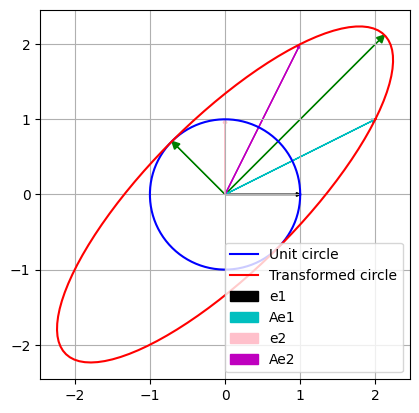

None


In [10]:
def plot_eigen(A):
    n=A.shape[0]
    eigenVal,eigenVec=np.linalg.eig(A)
    #defining a circle
    
    #Radius(for unit circle r=1)
    r=1
    
    #Angle
    theta=np.linspace(0,2*np.pi*r,100)#genrates a matrix of (100,1)
    
    #Draw cicle using Polar Coordinate Conversion
    circle=np.array([np.cos(theta),np.sin(theta)])
    
    #Draw ellipse
    ellipse= A@circle
     
    fig,ax=plt.subplots()
    ax.plot(circle[0],circle[1],'b-',label='Unit circle') 
    ax.plot(ellipse[0],ellipse[1],'r-',label='Transformed circle')
    
    #Standard Basis 
    e1 = np.array([1.0, 0.0])
    e2 = np.array([0.0, 1.0])
    s_basis = np.vstack((e1, e2))
    #Transfoemed basis
    Ae1 = A @ e1
    Ae2 = A @ e2
    Ts_basis = np.vstack((Ae1, Ae2))
    
    
    basis_colors = ['k', 'pink']
    trans_colors = ['c', 'm']
    
    
          
    #starting point
    x,y=0,0
    for i in range(n):
        dx=eigenVal[i]*eigenVec[0,i]#Direction and strech in x direction
        dy=eigenVal[i]*eigenVec[1,i]#Direction and strech in y direction
        ax.arrow(x,y,dx,dy,head_width=0.1,head_length=0.1,fc='g',ec='g',length_includes_head=True)
        ax.arrow(x, y,s_basis[0,i] ,s_basis[1,i] , head_width=0.05, head_length=0.05, fc=basis_colors[i], ec=basis_colors[i], label=f'e{i+1}',length_includes_head=True)
        ax.arrow(x, y,Ts_basis[0,i] ,Ts_basis[1,i] , head_width=0.05, head_length=0.05, fc=trans_colors[i], ec=trans_colors[i], label=f'Ae{i+1}',length_includes_head=True)
        
        
                
    ax.set_aspect('equal')
    ax.grid(True)
    ax.legend()
    plt.show()
    
    return 

#Only plots 2-D  array
B = np.array([[2, 1], [1, 2]])    
print(plot_eigen(B))

# Real-World Applications (Why We Use It)

### 1. Decoupling Dynamic Systems (Physics & Engineering)
In physical systems (like a bridge vibrating or a multi-story building reacting to an earthquake), the movement of one part depends directly on another. This creates a tangled web of coupled differential equations. 

Eigenvectors find the "natural modes" of the system, decoupling the equations so each component can be solved independently.

### 2. Dimensionality Reduction (Data Science & AI)
Datasets often contain hundreds of redundant features. In **Principal Component Analysis (PCA)**, data scientists compute the covariance matrix of a dataset. 
* The **eigenvectors** point in the directions of maximum variance (the trends holding the most information).
* The **eigenvalues** tell you how much information is packed into that direction. 
* Directions with tiny eigenvalues can be safely discarded, compressing the data without losing critical insight.

### 3. Long-Term Stability & Markov Chains (Computer Science)
When evaluating long-term behaviors (like web page authority or stock market predictions), you multiply state vectors by a transition matrix thousands of times ($A^{1000}$). Eigenvectors reveal the steady-state equilibrium point of the system. Google’s original **PageRank** algorithm uses the eigenvector belonging to $\lambda = 1$ to rank internet web pages.
